In [19]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from funcoes.funcoes_feat_eng import *
# Comum -------------------------------------
from sklearn.metrics import r2_score, mean_absolute_error
# Regressão linear --------------------------
from sklearn.linear_model import LinearRegression
# Random Forest -----------------------------
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
# XGBoost -----------------------------------
from xgboost import XGBRegressor





In [20]:
df = pd.read_csv('df_eng_feat.csv', sep=';', encoding='utf-8-sig')
df

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_living15,ano,...,sqft_basement_log,sqft_lot15_log,lot_15_compare_log,living_15_compare_log,mean_price_zipcode_log,waterfront_grade_log,living_grade_log,living_waterffront_log,waterfront_condition_log,luxury_log
0,3,1.00,1180,1.0,0,0,3,7,1340,2014,...,0.000000,8.639588,0.693147,0.631591,12.646305,0.0,9.019301,0.0,0.0,22.764094
1,3,2.25,2570,2.0,0,0,3,7,1690,2014,...,5.993961,8.941153,0.666803,0.924537,13.059331,0.0,9.797627,0.0,0.0,23.955513
2,2,1.00,770,1.0,0,0,3,6,2720,2015,...,0.000000,8.995041,0.806654,0.249279,13.044361,0.0,8.438366,0.0,0.0,22.581121
3,4,3.00,1960,1.0,0,0,5,7,1360,2014,...,6.814543,8.517393,0.693147,0.892490,13.220741,0.0,9.526683,0.0,0.0,24.356787
4,3,2.00,1680,1.0,0,0,3,8,1800,2015,...,0.000000,8.923191,0.730876,0.659228,13.438060,0.0,9.506065,0.0,0.0,24.042661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21591,3,2.50,1530,3.0,0,0,3,8,1530,2014,...,0.000000,7.319865,0.559330,0.693147,13.279074,0.0,9.412546,0.0,0.0,23.790149
21592,4,2.50,2310,2.0,0,0,3,8,1830,2015,...,0.000000,8.881975,0.591889,0.816382,12.792426,0.0,9.824498,0.0,0.0,23.715479
21593,2,0.75,1020,2.0,0,0,3,7,1020,2014,...,0.000000,7.604894,0.514379,0.693147,13.295558,0.0,8.873608,0.0,0.0,23.267636
21594,3,2.50,1600,2.0,0,0,3,8,1410,2015,...,0.000000,7.160846,1.049247,0.758373,13.332611,0.0,9.457279,0.0,0.0,23.888422


## Preparação final

In [21]:
# Variáveis preditoras (X) e a variável alvo (y)
X = df.drop(columns=['price_log'])
y = df['price_log']

# Treino (80%) e Teste (20%)
# O random_state garante que a divisão seja sempre a mesma ao rodar o código
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42)

# Verificando as proporções na tela
print(f"Dados de Treino: {X_train.shape[0]} linhas")
print(f"Dados de Teste: {X_test.shape[0]} linhas")

Dados de Treino: 17276 linhas
Dados de Teste: 4320 linhas


In [22]:
obter_listas_tratamento(df)

{'log': ['waterfront',
  'view',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'lot_15_compare_log',
  'waterfront_grade_log',
  'living_waterffront_log',
  'waterfront_condition_log'],
 'capping': ['view',
  'grade',
  'estacao_Outono',
  'estacao_Inverno',
  'bool_renovated_15',
  'sqft_lot_log',
  'sqft_lot15_log',
  'lot_15_compare_log',
  'living_15_compare_log'],
 'extremos': ['bedrooms',
  'bathrooms',
  'sqft_living',
  'waterfront',
  'condition',
  'sqft_living15',
  'final_de_semana',
  'fim_do_mes',
  'living_percent_total',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'bool_renovated',
  'living_more_than_lot',
  'dist_seattle',
  'dist_Bellevue',
  'dist_Redmond',
  'dist_Snoqualmie',
  'dist_Mountdaniel',
  'dist_vashonisland',
  'dist_SeaTac',
  'price_log',
  'mean_price_zipcode_log',
  'waterfront_grade_log',
  'living_grade_log',
  'living_waterffront_log',
  'waterfro

In [23]:
# Garante que as colunas que vão sofrer capping estão aqui
# (Substitua pela sua variável se ela já estiver na memória)
colunas_capping =  ['view',
  'grade',
  'estacao_Outono',
  'estacao_Inverno',
  'bool_renovated_15',
  'sqft_lot_log',
  'sqft_lot15_log',
  'lot_15_compare_log',
  'living_15_compare_log']

for col in colunas_capping:
    # 1. Calcula os limites do IQR baseados APENAS no conjunto de TREINO
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    
    # 2. Limita (clipa) os valores em ambos os conjuntos usando os limites do treino
    X_train[col] = X_train[col].clip(lower=limite_inf, upper=limite_sup)
    X_test[col] = X_test[col].clip(lower=limite_inf, upper=limite_sup)

print("Capping aplicado com sucesso em treino e teste!")

Capping aplicado com sucesso em treino e teste!


## Regressão Linear

In [24]:
# Instanciar e Treinar o Modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predições (ainda na escala LOG)
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# Conversão monetária original
# np.expm1 == o log foi aplicado com np.log1p
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

# Métricas de Avaliação
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)

# Resultados
print("=== RESULTADOS DA REGRESSÃO LINEAR ===")
print(f"R² (Treino): {r2_train:.4f}")
print(f"R² (Teste) : {r2_test:.4f} (Meta: quanto mais perto de 1.0, melhor)")
print(f"Erro Médio Absoluto (MAE): U$ {mae_real:,.2f} (Erro médio real por casa)")

=== RESULTADOS DA REGRESSÃO LINEAR ===
R² (Treino): 0.8766
R² (Teste) : 0.8688 (Meta: quanto mais perto de 1.0, melhor)
Erro Médio Absoluto (MAE): U$ 77,157.89 (Erro médio real por casa)


## RandomForest

In [25]:
# Instanciar e Treinar o Modelo
# ---> n_jobs=-1 = velocidade máxima e alguns hiperparâmetros padrão de boa prática
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predições (ainda na escala LOG)
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Conversão monetária original
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

# Métricas de Avaliação
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)

# Resultados
print("=== RESULTADOS DO RANDOM FOREST ===")
print(f"R² (Treino): {r2_train:.4f}")
print(f"R² (Teste) : {r2_test:.4f}")
print(f"Erro Médio Absoluto (MAE): U$ {mae_real:,.2f}")

=== RESULTADOS DO RANDOM FOREST ===
R² (Treino): 0.9850
R² (Teste) : 0.8944
Erro Médio Absoluto (MAE): U$ 67,631.48


In [26]:
# Definir o espaço de parâmetros específicos para Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],           # None significa sem limite de profundidade
    'min_samples_split': [2, 5, 10],           # Evita que a árvore crie ramos muito específicos
    'min_samples_leaf': [1, 2, 4],             # Garante que cada folha tenha um grupo mínimo de casas
    'max_features': ['sqrt', 'log2', None]     # Quantidade de colunas avaliadas por divisão (None = todas)
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configurar o RandomizedSearch
tuning_rf = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist_rf, 
    n_iter=15, ##TROCAR PARA GRIDSEARCHCV??
    scoring='r2', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

# Rodar a busca
tuning_rf.fit(X_train, y_train)

print("=== MELHORES PARÂMETROS DO RANDOM FOREST ===")
print(tuning_rf.best_params_)

=== MELHORES PARÂMETROS DO RANDOM FOREST ===
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [27]:
# Sem conversão monetária inicial
# Pega o melhor estimador encontrado
melhor_rf = tuning_rf.best_estimator_

# Predições e conversão de escala
y_pred_rf_best_log = melhor_rf.predict(X_test)
y_pred_rf_best_real = np.expm1(y_pred_rf_best_log)
y_test_real = np.expm1(y_test)

# Métricas
r2_rf_best = r2_score(y_test, y_pred_rf_best_log)
mae_rf_best = mean_absolute_error(y_test_real, y_pred_rf_best_real)

print("=== NOVO RANDOM FOREST (OTIMIZADO) ===")
print(f"Novo R² (Teste) : {r2_rf_best:.4f} (Anterior era: 0.8835)")
print(f"Novo Erro (MAE) : U$ {mae_rf_best:,.2f} (Anterior era: U$ 71,541.24)")

=== NOVO RANDOM FOREST (OTIMIZADO) ===
Novo R² (Teste) : 0.8981 (Anterior era: 0.8835)
Novo Erro (MAE) : U$ 65,838.91 (Anterior era: U$ 71,541.24)


In [28]:
# Com conversão monetária inicial
# Instanciar e Treinar o Modelo
# ---> n_jobs=-1 = velocidade máxima e alguns hiperparâmetros padrão de boa prática
rf_model = RandomForestRegressor(n_estimators= 300, min_samples_split= 2, min_samples_leaf= 1, max_features= 'sqrt', max_depth= 20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predições (ainda na escala LOG)
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Conversão monetária original
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

# Métricas de Avaliação
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)

# Resultados
print("=== RESULTADOS DO RANDOM FOREST ===")
print(f"R² (Treino): {r2_train:.4f}")
print(f"R² (Teste) : {r2_test:.4f}")
print(f"Erro Médio Absoluto (MAE): U$ {mae_real:,.2f}")

=== RESULTADOS DO RANDOM FOREST ===
R² (Treino): 0.9844
R² (Teste) : 0.8981
Erro Médio Absoluto (MAE): U$ 65,838.91


## XGBoost

In [29]:
# Instanciar e Treinar o Modelo
# ---> n_jobs=-1 = velocidade máxima e alguns hiperparâmetros padrão de boa prática
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.08, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Predições (ainda na escala LOG)
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Conversão monetária original
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

# Métricas de Avaliação
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)

# Resultados
print("=== RESULTADOS DO XGBOOST ===")
print(f"R² (Treino): {r2_train:.4f}")
print(f"R² (Teste) : {r2_test:.4f}")
print(f"Erro Médio Absoluto (MAE): U$ {mae_real:,.2f}")

=== RESULTADOS DO XGBOOST ===
R² (Treino): 0.9356
R² (Teste) : 0.9034
Erro Médio Absoluto (MAE): U$ 63,243.64


In [30]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Teste de combinações aleatórias (velocidade > GridSearch)
tuning = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=15,
    scoring='r2', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

tuning.fit(X_train, y_train)
print("Melhores parâmetros encontrados:", tuning.best_params_)


Melhores parâmetros encontrados: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [31]:
# Novo modelo otimizado
melhor_xgb = tuning.best_estimator_

# Predições
y_pred_best_log = melhor_xgb.predict(X_test)
y_pred_best_real = np.expm1(y_pred_best_log)
y_test_real = np.expm1(y_test)

# Recalculando as métricas
from sklearn.metrics import r2_score, mean_absolute_error
r2_best = r2_score(y_test, y_pred_best_log)
mae_best = mean_absolute_error(y_test_real, y_pred_best_real)

print("=== NOVO MODELO XGBOOST (OTIMIZADO) ===")
print(f"Novo R² (Teste) : {r2_best:.4f} (Anterior era: 0.8924)")
print(f"Novo Erro (MAE) : U$ {mae_best:,.2f} (Anterior era: U$ 68,417.49)")

=== NOVO MODELO XGBOOST (OTIMIZADO) ===
Novo R² (Teste) : 0.9089 (Anterior era: 0.8924)
Novo Erro (MAE) : U$ 60,686.89 (Anterior era: U$ 68,417.49)


In [32]:
# Teste
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

# 1. Criar a função que calcula o erro na escala real de dólares
def mae_em_dolar(y_true_log, y_pred_log):
    y_true_real = np.expm1(y_true_log)
    y_pred_real = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_real, y_pred_real)

# 2. Transformar a função em um avaliador oficial do Scikit-Learn
# greater_is_better=False indica que o algoritmo deve buscar o MENOR erro possível
scorer_dolar = make_scorer(mae_em_dolar, greater_is_better=False)

# 3. Configurar o espaço de parâmetros do XGBoost
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

# 4. Rodar a busca com o novo avaliador (testando 40 combinações)
tuning_dolar = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=40, 
    scoring=scorer_dolar, # <-- O segredo está aqui
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

tuning_dolar.fit(X_train, y_train)
print("Melhores parâmetros focados em Dólares:", tuning_dolar.best_params_)

Melhores parâmetros focados em Dólares: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [33]:
melhor_xgb_dolar = tuning_dolar.best_estimator_

# Predições e conversão
y_pred_log = melhor_xgb_dolar.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# Métricas
r2_final = r2_score(y_test, y_pred_log)
mae_final = mean_absolute_error(y_test_real, y_pred_real)

print("=== NOVO XGBOOST OTIMIZADO EM DÓLAR ===")
print(f"R² (Teste) : {r2_final:.4f}")
print(f"Erro (MAE) : U$ {mae_final:,.2f}")

=== NOVO XGBOOST OTIMIZADO EM DÓLAR ===
R² (Teste) : 0.9089
Erro (MAE) : U$ 60,686.89


# Esemble

In [34]:
# VotingRegressor + melhor modelo XGBoost e RandomForest
ensemble_ponderado = VotingRegressor(estimators=[
    ('xgb_otimizado', melhor_xgb),
    ('random_forest', rf_model)],
    weights=[0.9, 0.1])

# Treinamento de modelos (2 modelos individuais)
ensemble_ponderado.fit(X_train, y_train)

# Predições (ainda na escala LOG)
y_pred_weighted_log = ensemble_ponderado.predict(X_test)
y_pred_weighted_real = np.expm1(y_pred_weighted_log)

r2_weighted = r2_score(y_test, y_pred_weighted_log)
mae_weighted = mean_absolute_error(y_test_real, y_pred_weighted_real)

# 6. Exibir Resultados
print("=== RESULTADOS DO ENSEMBLE (VOTING) ===")
print(f"R² (Teste) : {r2_weighted:.4f} (Meta: passar de 0.8999)")
print(f"Erro (MAE) : U$ {mae_weighted:,.2f} (Meta: ser menor que U$ 64,796.37)")

=== RESULTADOS DO ENSEMBLE (VOTING) ===
R² (Teste) : 0.9089 (Meta: passar de 0.8999)
Erro (MAE) : U$ 60,733.53 (Meta: ser menor que U$ 64,796.37)


## Feature importance

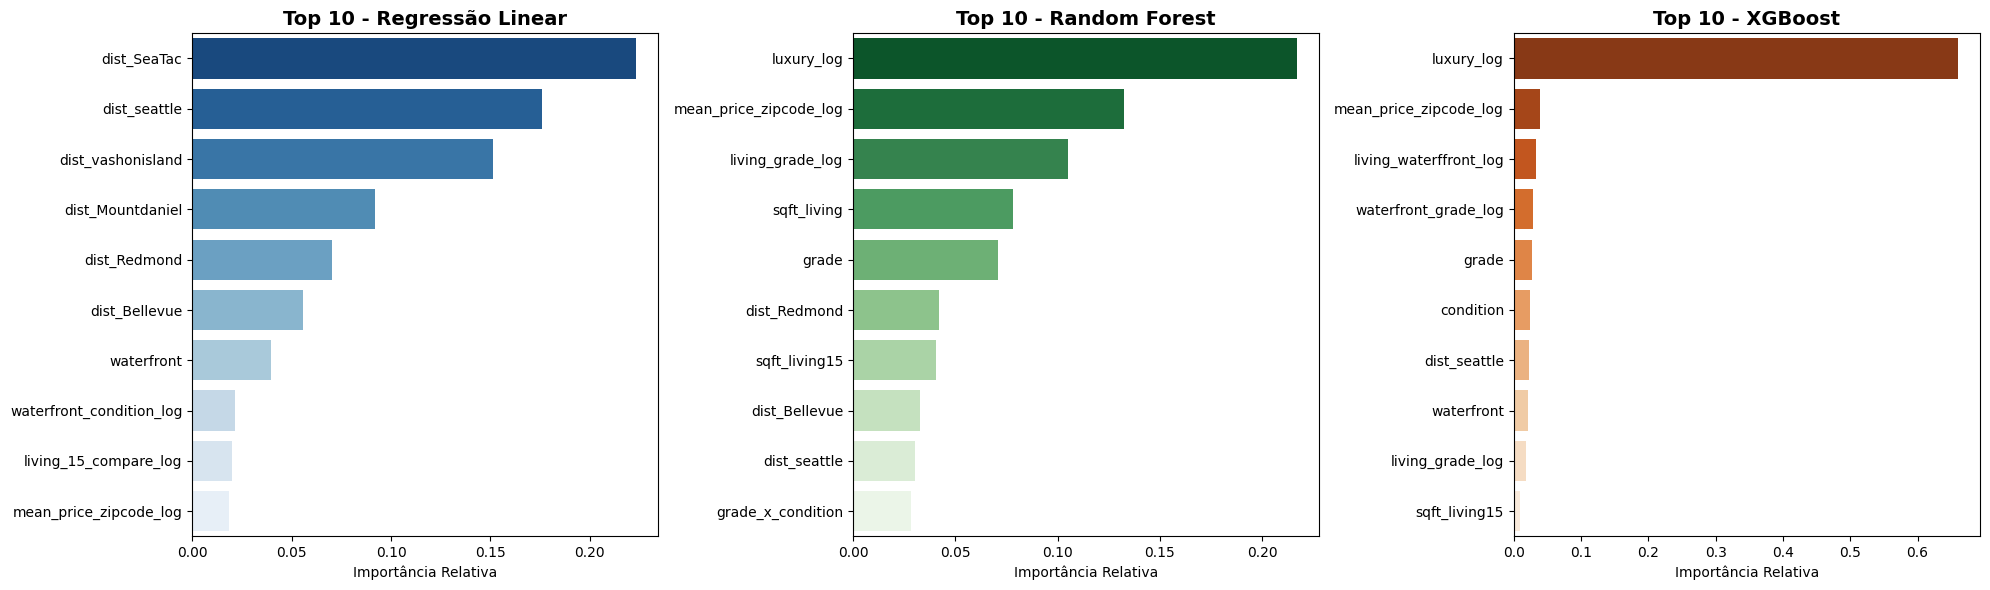

In [35]:
# Extrair as importâncias de cada modelo
recursos = X_train.columns

# Regressão Linear
coef_absolutos = np.abs(lr_model.coef_)
importancia_lr = coef_absolutos / np.sum(coef_absolutos)

# Random Forest e XGBoost
importancia_rf = rf_model.feature_importances_
importancia_xgb = xgb_model.feature_importances_

# DF Comparativo
df_importancias = pd.DataFrame({
    'Variável': recursos,
    'Regressão Linear': importancia_lr,
    'Random Forest': importancia_rf,
    'XGBoost': importancia_xgb
})

# Config de plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
modelos = ['Regressão Linear', 'Random Forest', 'XGBoost']
paletas = ['Blues_r', 'Greens_r', 'Oranges_r']

for i, modelo in enumerate(modelos):
    # Top 10
    df_top10 = df_importancias[['Variável', modelo]].sort_values(by=modelo, ascending=False).head(10)
    
    sns.barplot(
        data=df_top10, 
        y='Variável', 
        x=modelo, 
        ax=axes[i], 
        palette=paletas[i],
        hue='Variável',
        legend=False
    )
    axes[i].set_title(f'Top 10 - {modelo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Importância Relativa')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

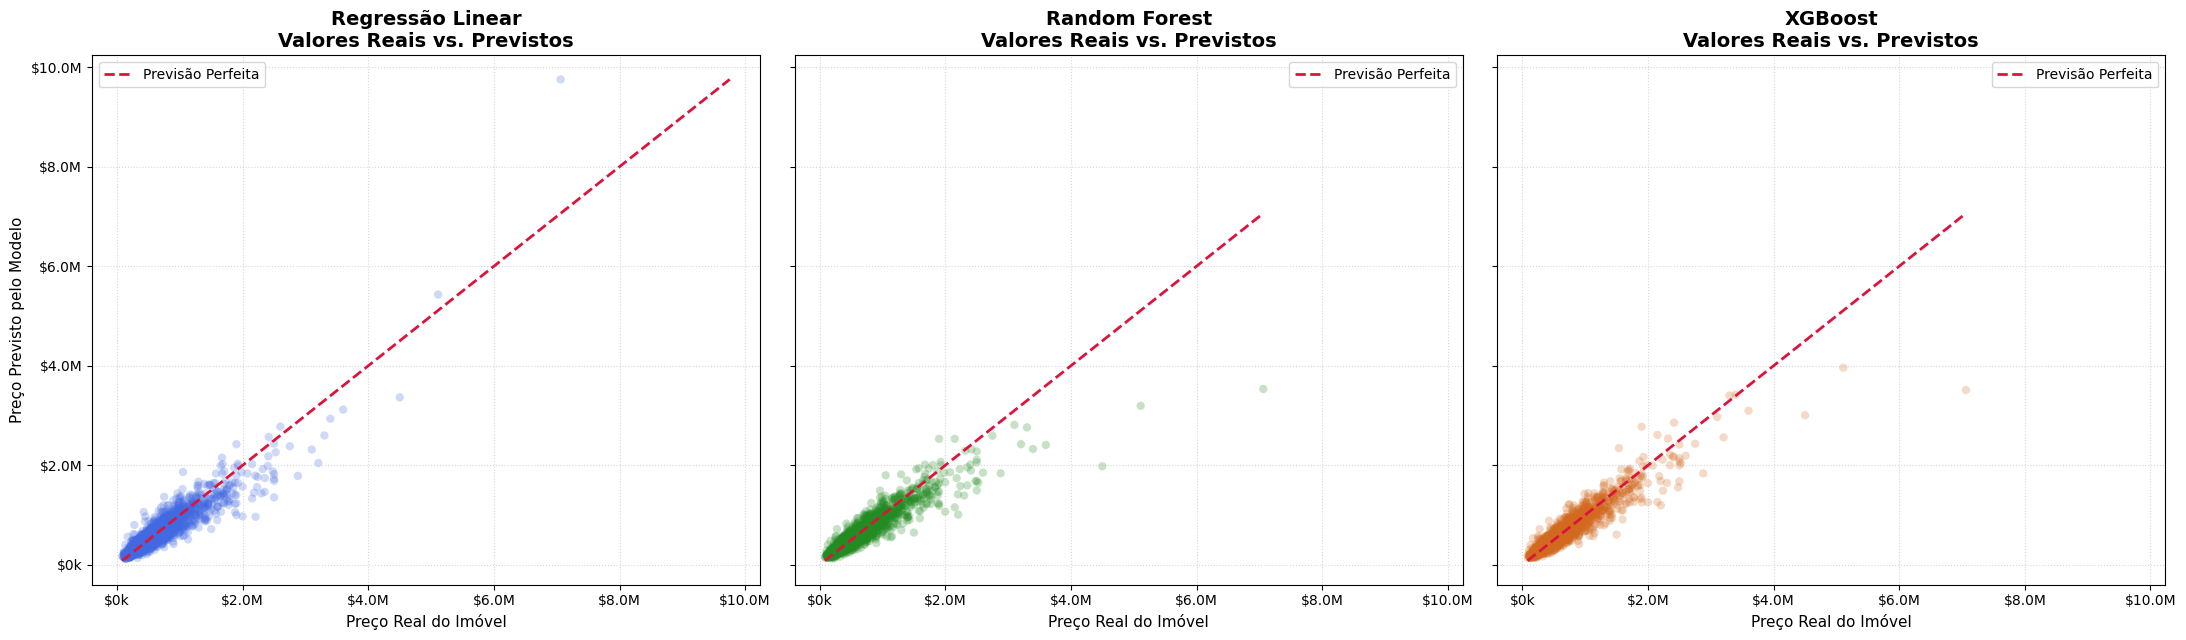

In [36]:
# SUBESTIMAÇÃO | SUPERESTIMAÇÃO
# Gerar as predições de todos os modelos na escala monetária real
y_test_real = np.expm1(y_test)
y_pred_lr = np.expm1(lr_model.predict(X_test))
y_pred_rf = np.expm1(rf_model.predict(X_test))
y_pred_xgb = np.expm1(xgb_model.predict(X_test))

# Config de plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True, sharex=True)

dados_plot = [
    ("Regressão Linear", y_pred_lr, "royalblue"),
    ("Random Forest", y_pred_rf, "forestgreen"),
    ("XGBoost", y_pred_xgb, "chocolate")
]

for i, (nome, y_pred, cor) in enumerate(dados_plot):
    # Pontos reais vs Previstos
    sns.scatterplot(
        x=y_test_real, 
        y=y_pred, 
        ax=axes[i], 
        color=cor, 
        alpha=0.25, 
        edgecolor='none'
    )
    
    # Previsão perfeita
    limite_max = max(y_test_real.max(), y_pred.max())
    limite_min = min(y_test_real.min(), y_pred.min())
    axes[i].plot([limite_min, limite_max], [limite_min, limite_max], color='crimson', linestyle='--', linewidth=2, label='Previsão Perfeita')
    
    # Títulos e formatações
    axes[i].set_title(f'{nome}\nValores Reais vs. Previstos', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Preço Real do Imóvel', fontsize=11)
    if i == 0:
        axes[i].set_ylabel('Preço Previsto pelo Modelo', fontsize=11)
    
    # Formatação dos valores
    formatter = plt.FuncFormatter(lambda val, pos: f'${val*1e-6:.1f}M' if val >= 1e6 else f'${val*1e-3:.0f}k')
    axes[i].xaxis.set_major_formatter(formatter)
    axes[i].yaxis.set_major_formatter(formatter)
    
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()